In [1]:
import pandas as pd
import numpy as np
from matplotlib import dates
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import gridspec

matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'NanumGothic'

data = pd.read_csv('2016_2020.csv')
data['REG_DTIME'] = pd.to_datetime(data['REG_DTIME'])
data['year'] = data['REG_DTIME'].dt.year
data['month'] = data['REG_DTIME'].dt.month
data['day'] = data['REG_DTIME'].dt.day

In [2]:
train_data = pd.read_csv('data.csv')
train_data['REG_DTIME'] = pd.to_datetime(train_data['REG_DTIME'])
train_data['year'] = train_data['REG_DTIME'].dt.year
train_data['month'] = train_data['REG_DTIME'].dt.month
train_data['day'] = train_data['REG_DTIME'].dt.day

In [3]:
def year_df_sum(df , year):
    df = df[df['year'] == year] 
    arg_df = df.groupby(['year','month','day', 'h_dong']).sum()
    arg_df = arg_df.reset_index(level=['year','month','day','h_dong'])
    return arg_df

def year_df_mean(df , year):
    df = df[df['year'] == year] 
    arg_df = df.groupby(['year','month','day', 'h_dong']).mean()
    arg_df = arg_df.reset_index(level=['year','month','day','h_dong'])
    return arg_df

In [4]:
def get_col_heatmap(arg_df, col,year):
    heat_df = pd.DataFrame()

    for dong in data['h_dong'].unique():
        heat_df[dong] = arg_df[arg_df['h_dong'] == dong][col].to_list()
    dt = pd.date_range(f'{year}/1/1', f'{year}/12/31', freq='d')
    
    if len(heat_df.index) != len(dt):
        heat_df = heat_df[:-1]
    heat_df.index = pd.date_range(f'{year}/1/1', f'{year}/12/31', freq='d')
    

    fig = plt.figure(figsize=(25, 40))
    gs = gridspec.GridSpec(nrows=4, # row 몇 개 
                           ncols=1, # col 몇 개 
                           height_ratios=[1,1,1,1], 
                           width_ratios=[1])
    gs.update(wspace=0.1, hspace=0.4)
    
    for i in range(4):
        ax = plt.subplot(gs[i,0])
        heat_s = heat_df[i*90 : (i+1)*90].T
        ax.set_title(f' {col} columns heatmap  {str(heat_s.columns[0])[:-8]} ~ {str(heat_s.columns[-1])[:-8]}' , fontsize = 20)
        ax.set_yticks(range(len(heat_s.index)),heat_s.index , fontsize = 10)
        ax.set_xticks(range(len(heat_s.columns)),heat_s.columns , fontsize = 10,rotation=45 )
        
        cb = ax.pcolor(heat_s , cmap=matplotlib.cm.Blues)
        plt.colorbar(cb)
        

In [5]:
def get_col_heatmap_test(arg_df, col,year):
    heat_df = pd.DataFrame()

    for dong in data['h_dong'].unique():
        heat_df[dong] = arg_df[arg_df['h_dong'] == dong][col].to_list()
    dt = pd.date_range(f'{year}/1/1', f'{year}/12/31', freq='d')
    
    if len(heat_df.index) != len(dt):
        heat_df = heat_df[:-1]
    heat_df.index = pd.date_range(f'{year}/1/1', f'{year}/12/31', freq='d')
    

    fig = plt.figure(figsize=(25, 40))
    gs = gridspec.GridSpec(nrows=4, # row 몇 개 
                           ncols=1, # col 몇 개 
                           height_ratios=[1,1,1,1], 
                           width_ratios=[1])
    gs.update(wspace=0.1, hspace=0.4)
    
    for i in range(1):
        ax = plt.subplot(gs[i,0])
        heat_s = heat_df[i*90 : (i+1)*90].T
        ax.set_title(f' {col} columns heatmap  {str(heat_s.columns[0])[:-8]} ~ {str(heat_s.columns[-1])[:-8]}' , fontsize = 20)
        ax.set_yticks(range(len(heat_s.index)),heat_s.index , fontsize = 10)
        ax.set_xticks(range(len(heat_s.columns)),heat_s.columns , fontsize = 10,rotation=45 )
        
        cb = ax.pcolor(heat_s , cmap=matplotlib.cm.Blues)
        plt.colorbar(cb)
        

## count 비교  

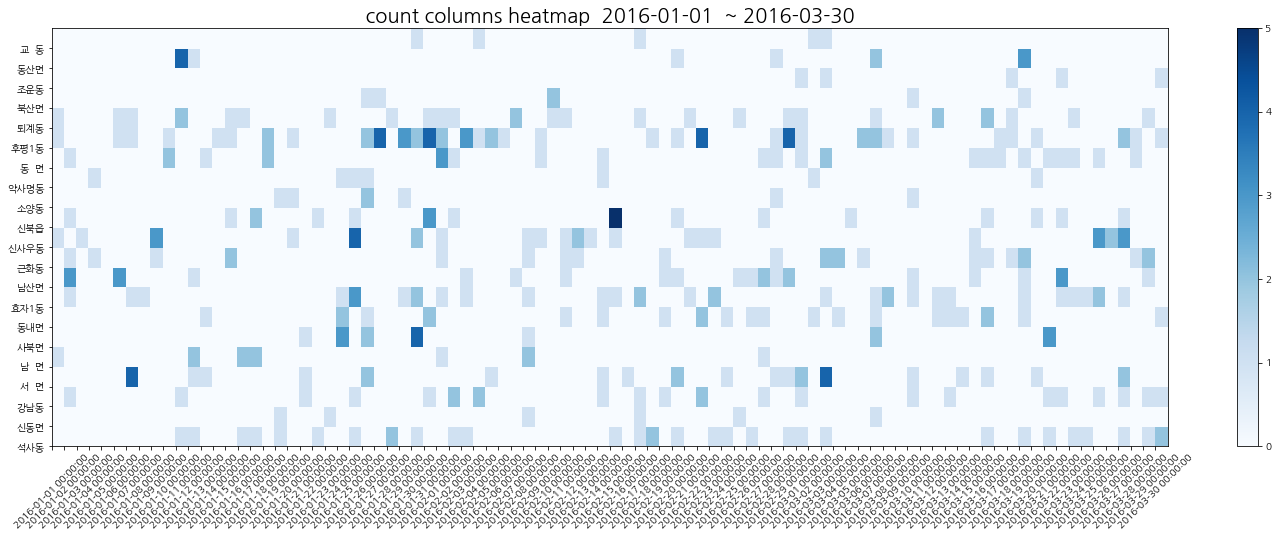

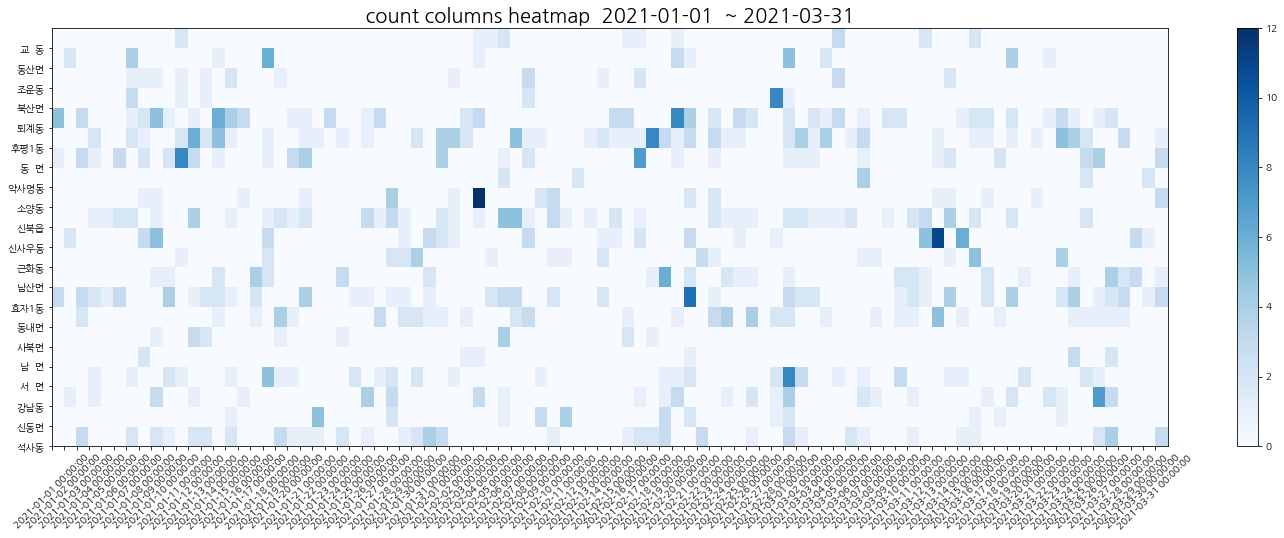

In [6]:
y_df = year_df_sum(data , 2016)
get_col_heatmap_test(y_df, 'count' , 2016)

y_df = year_df_sum(train_data , 2021)
get_col_heatmap_test(y_df, 'count' , 2021)

## 풍속 비교

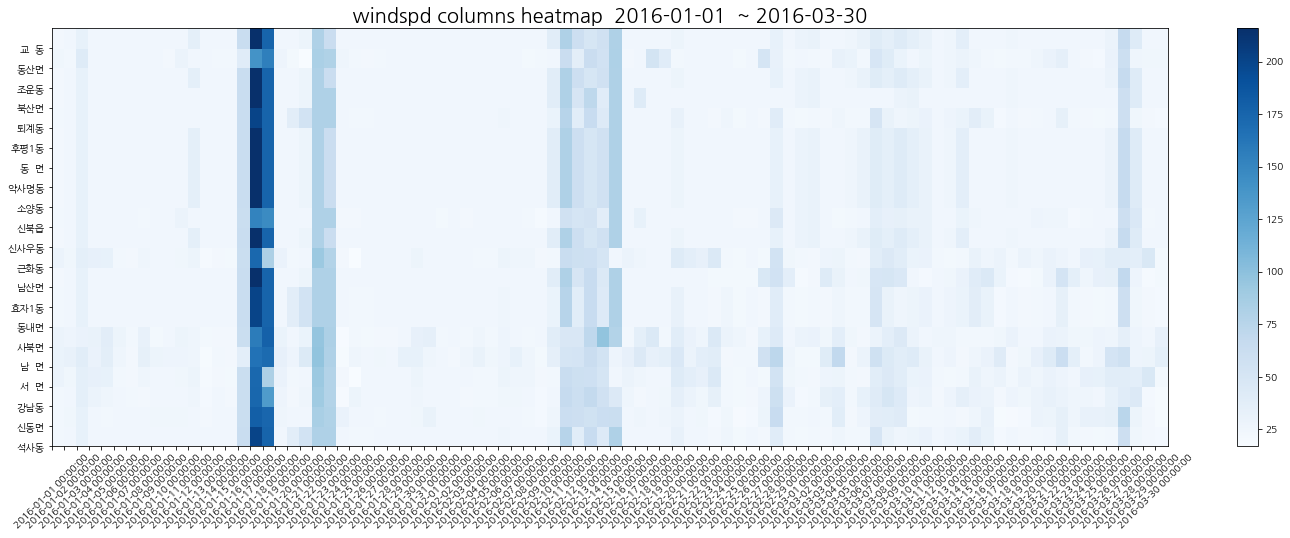

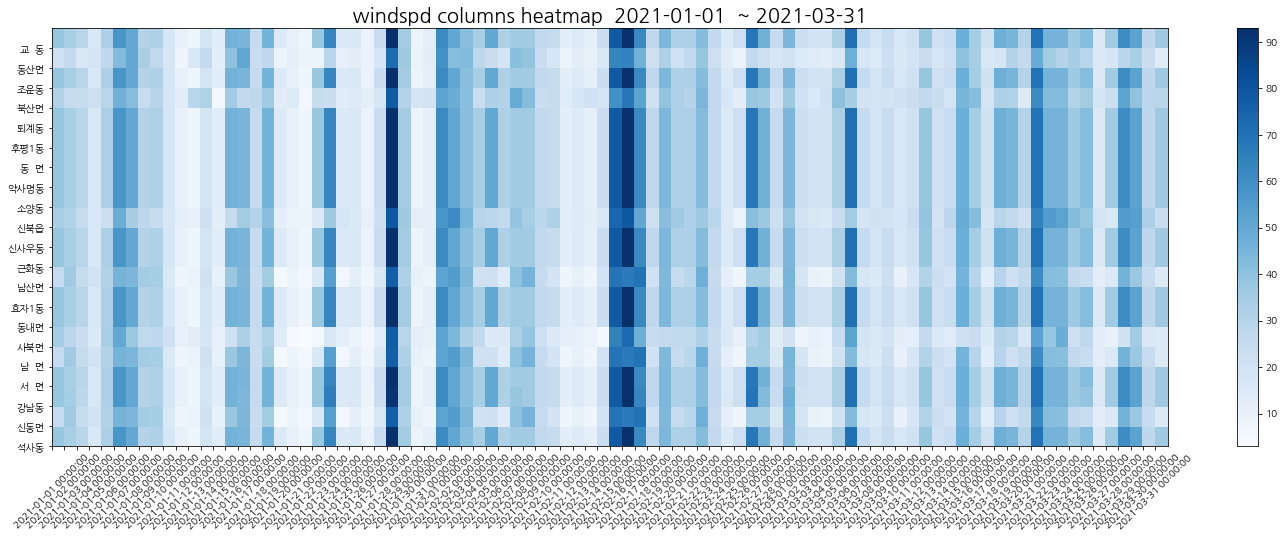

In [7]:
y_df = year_df_sum(data , 2016)
get_col_heatmap_test(y_df, 'windspd' , 2016)
y_df = year_df_sum(train_data , 2021)
get_col_heatmap_test(y_df, 'windspd' , 2021)

## 습도 비교

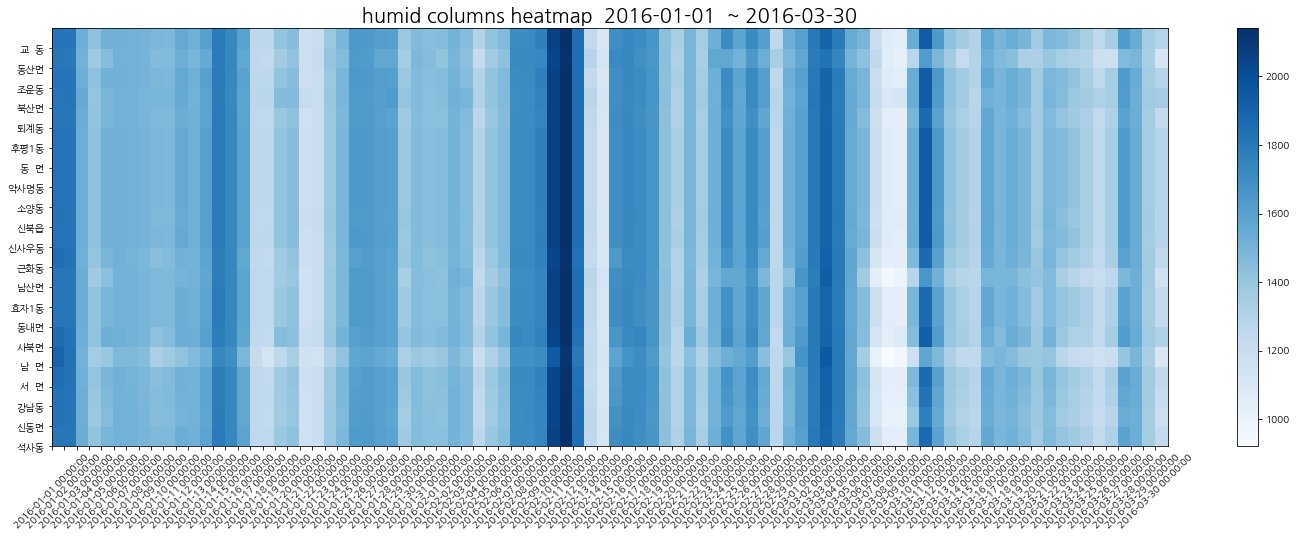

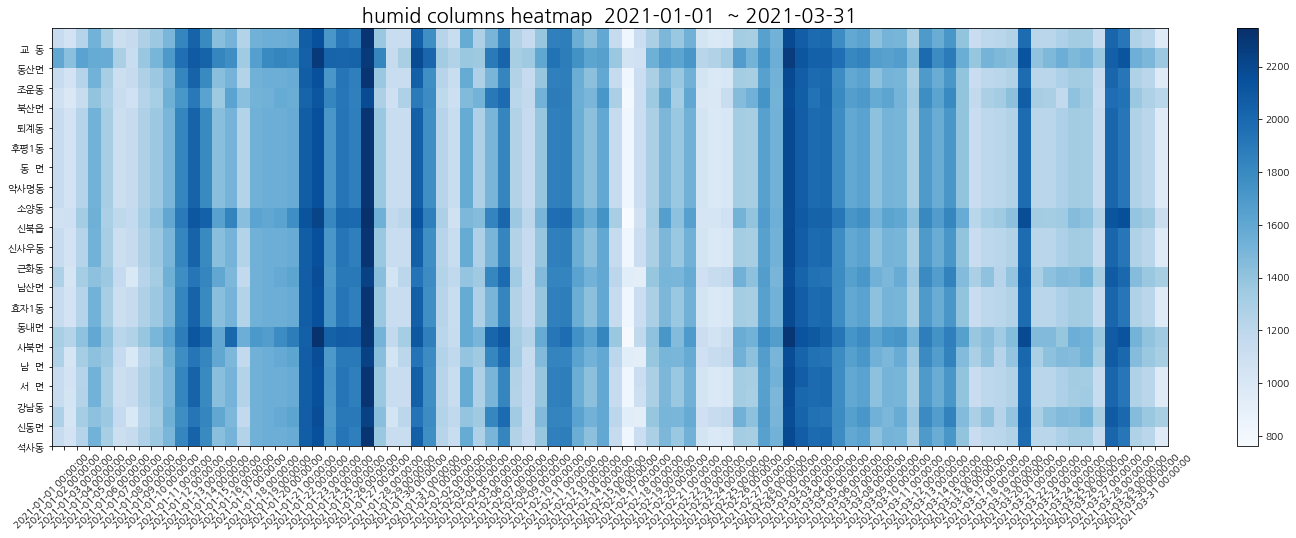

In [8]:
y_df = year_df_sum(data , 2016)
get_col_heatmap_test(y_df, 'humid' , 2016)
y_df = year_df_sum(train_data , 2021)
get_col_heatmap_test(y_df, 'humid' , 2021)

##  기온 비교

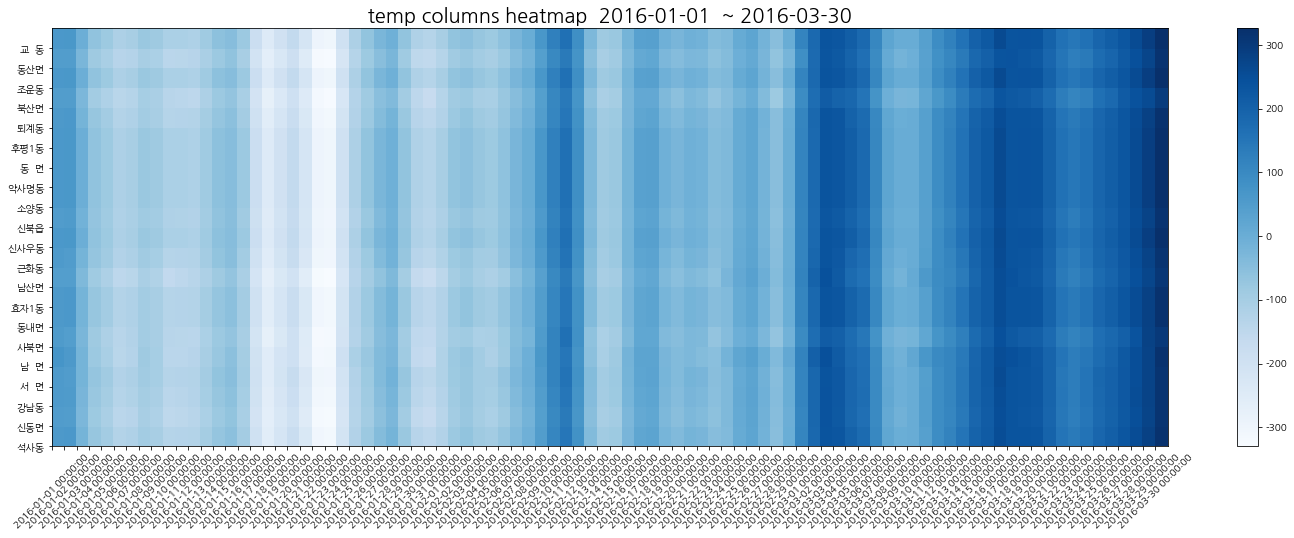

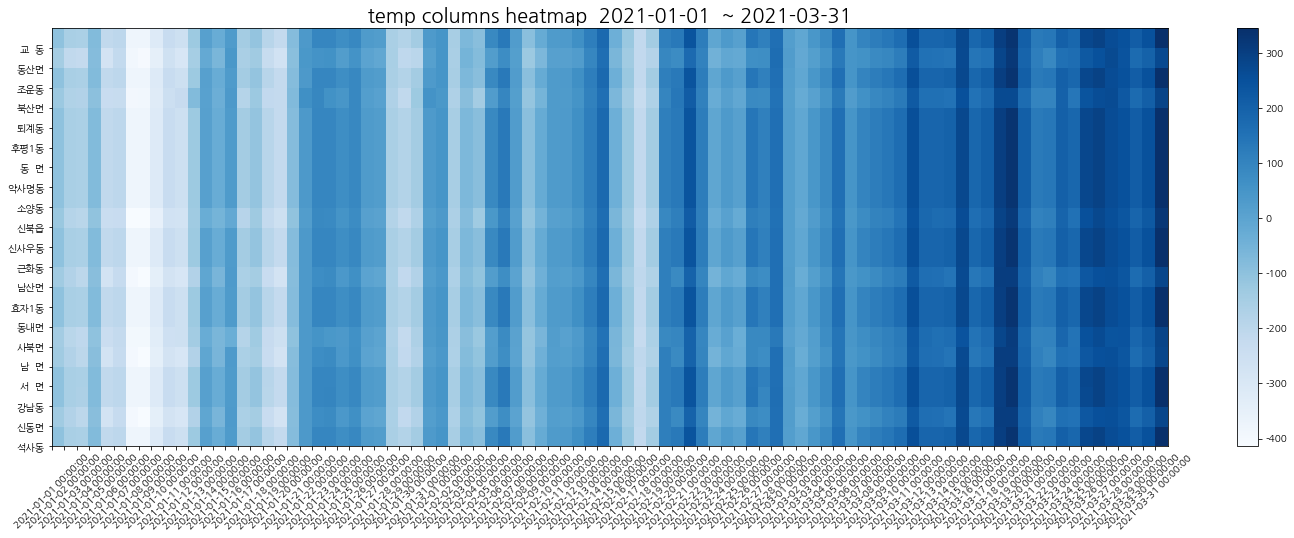

In [9]:
y_df = year_df_sum(data , 2016)
get_col_heatmap_test(y_df, 'temp' , 2016)
y_df = year_df_sum(train_data , 2021)
get_col_heatmap_test(y_df, 'temp' , 2021)

## 강수형태 비교

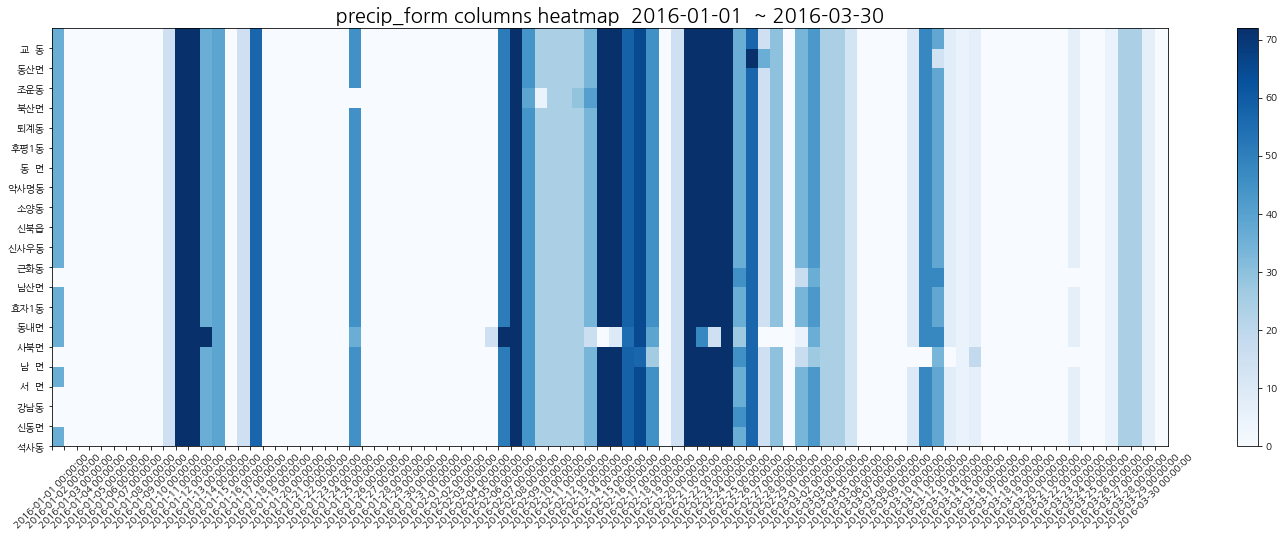

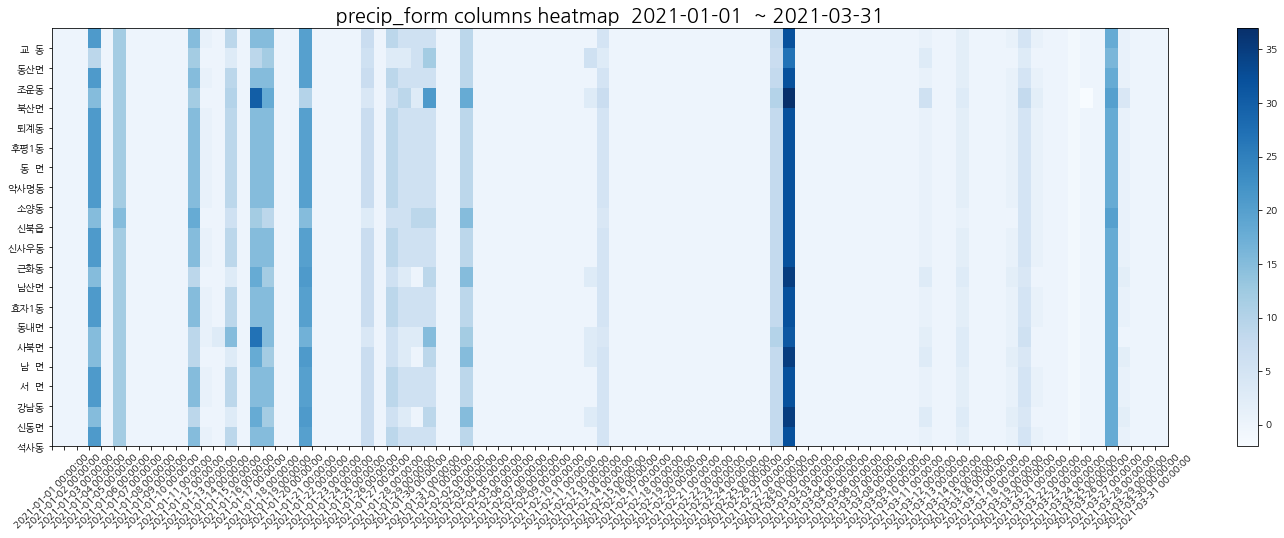

In [10]:
y_df = year_df_sum(data , 2016)
get_col_heatmap_test(y_df, 'precip_form' , 2016)
y_df = year_df_sum(train_data , 2021)
get_col_heatmap_test(y_df, 'precip_form' , 2021)

## 강수량 비교

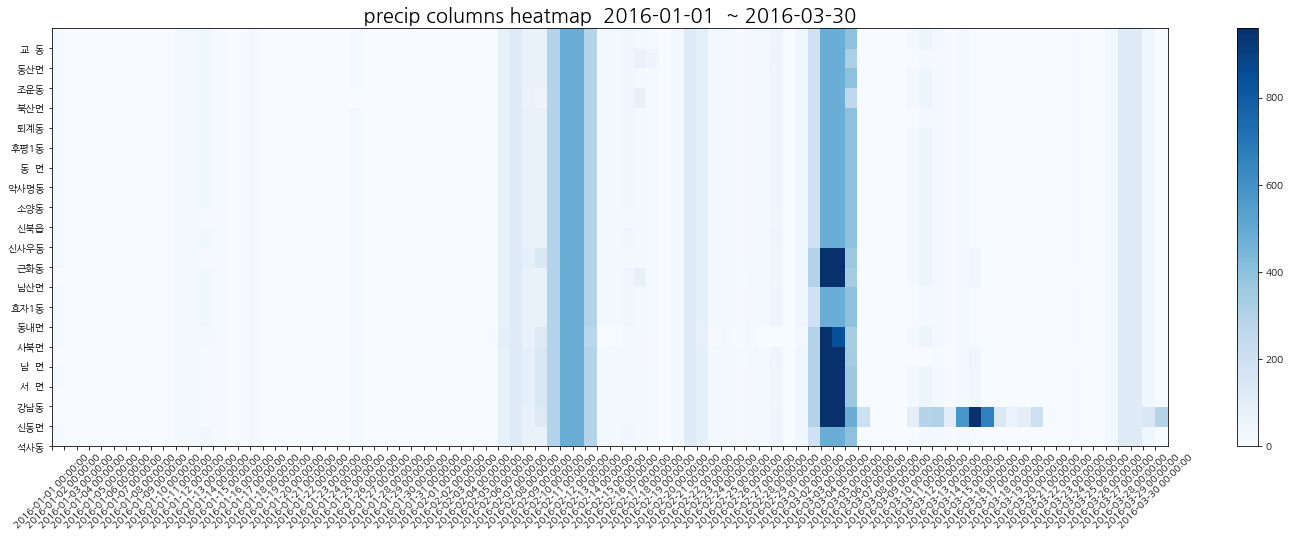

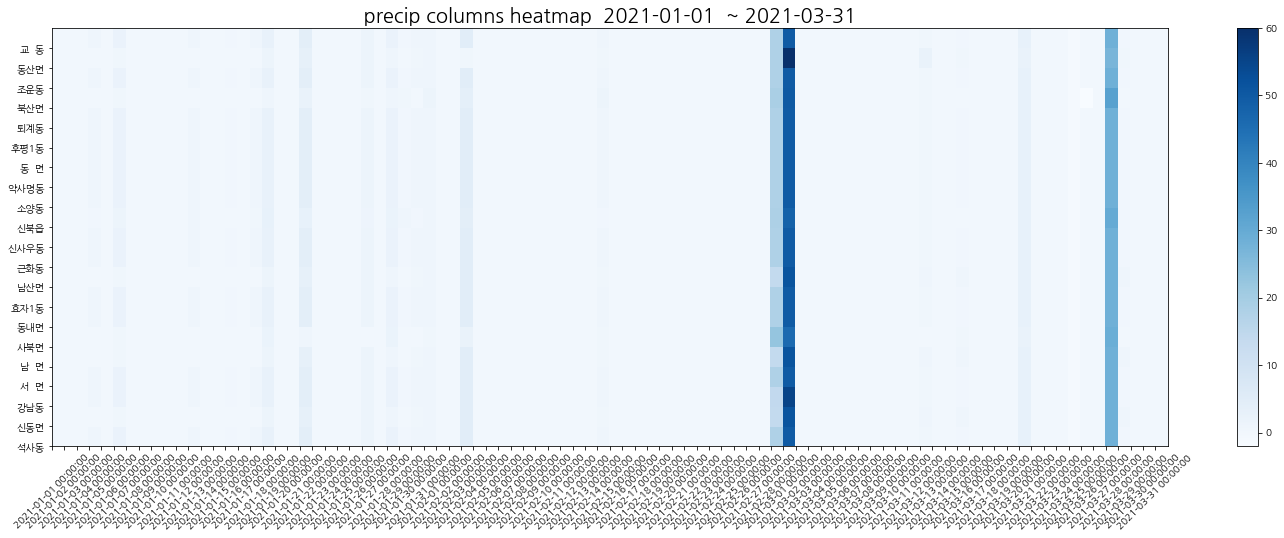

In [11]:
y_df = year_df_sum(data , 2016)
get_col_heatmap_test(y_df, 'precip' , 2016)
y_df = year_df_sum(train_data , 2021)
get_col_heatmap_test(y_df, 'precip' , 2021)

## 인구수 비교 

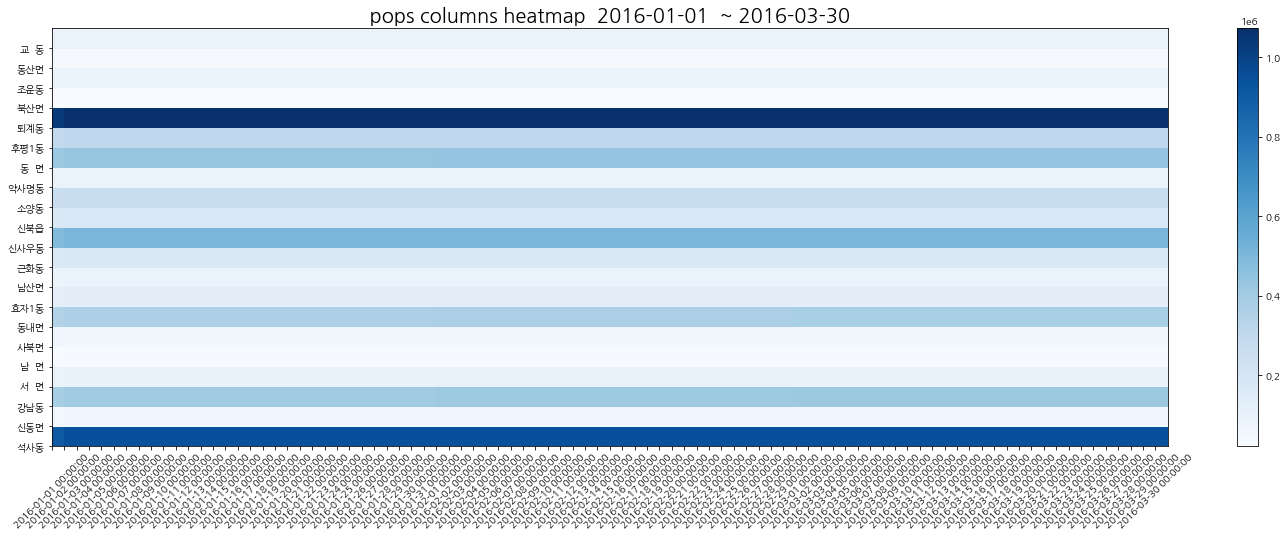

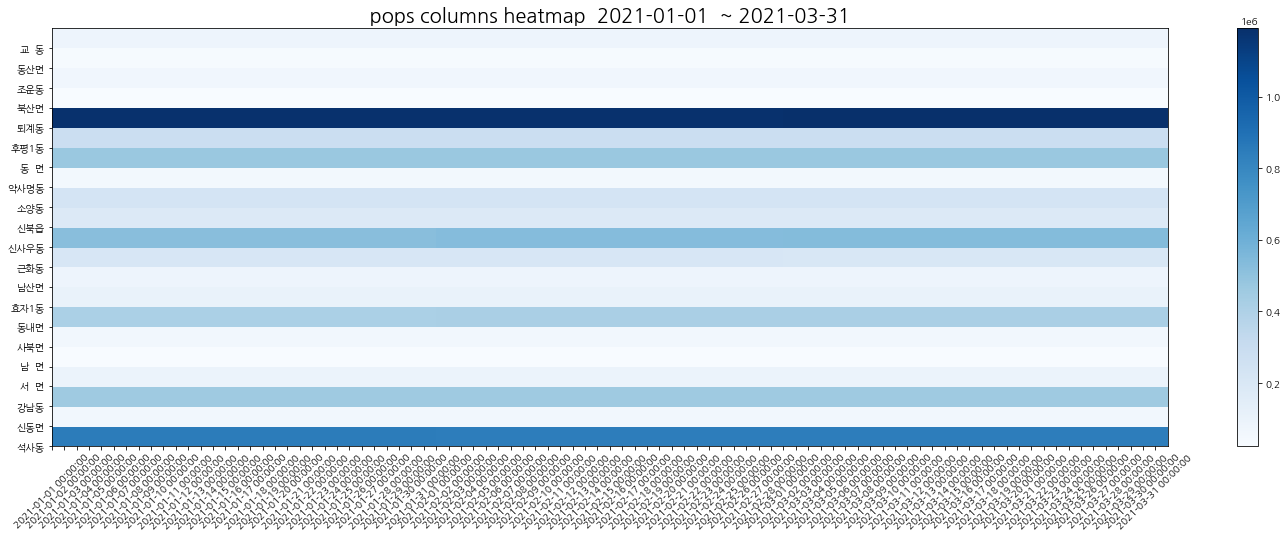

In [12]:
y_df = year_df_sum(data , 2016)
get_col_heatmap_test(y_df, 'pops' , 2016)
y_df = year_df_sum(train_data , 2021)
get_col_heatmap_test(y_df, 'pops' , 2021)

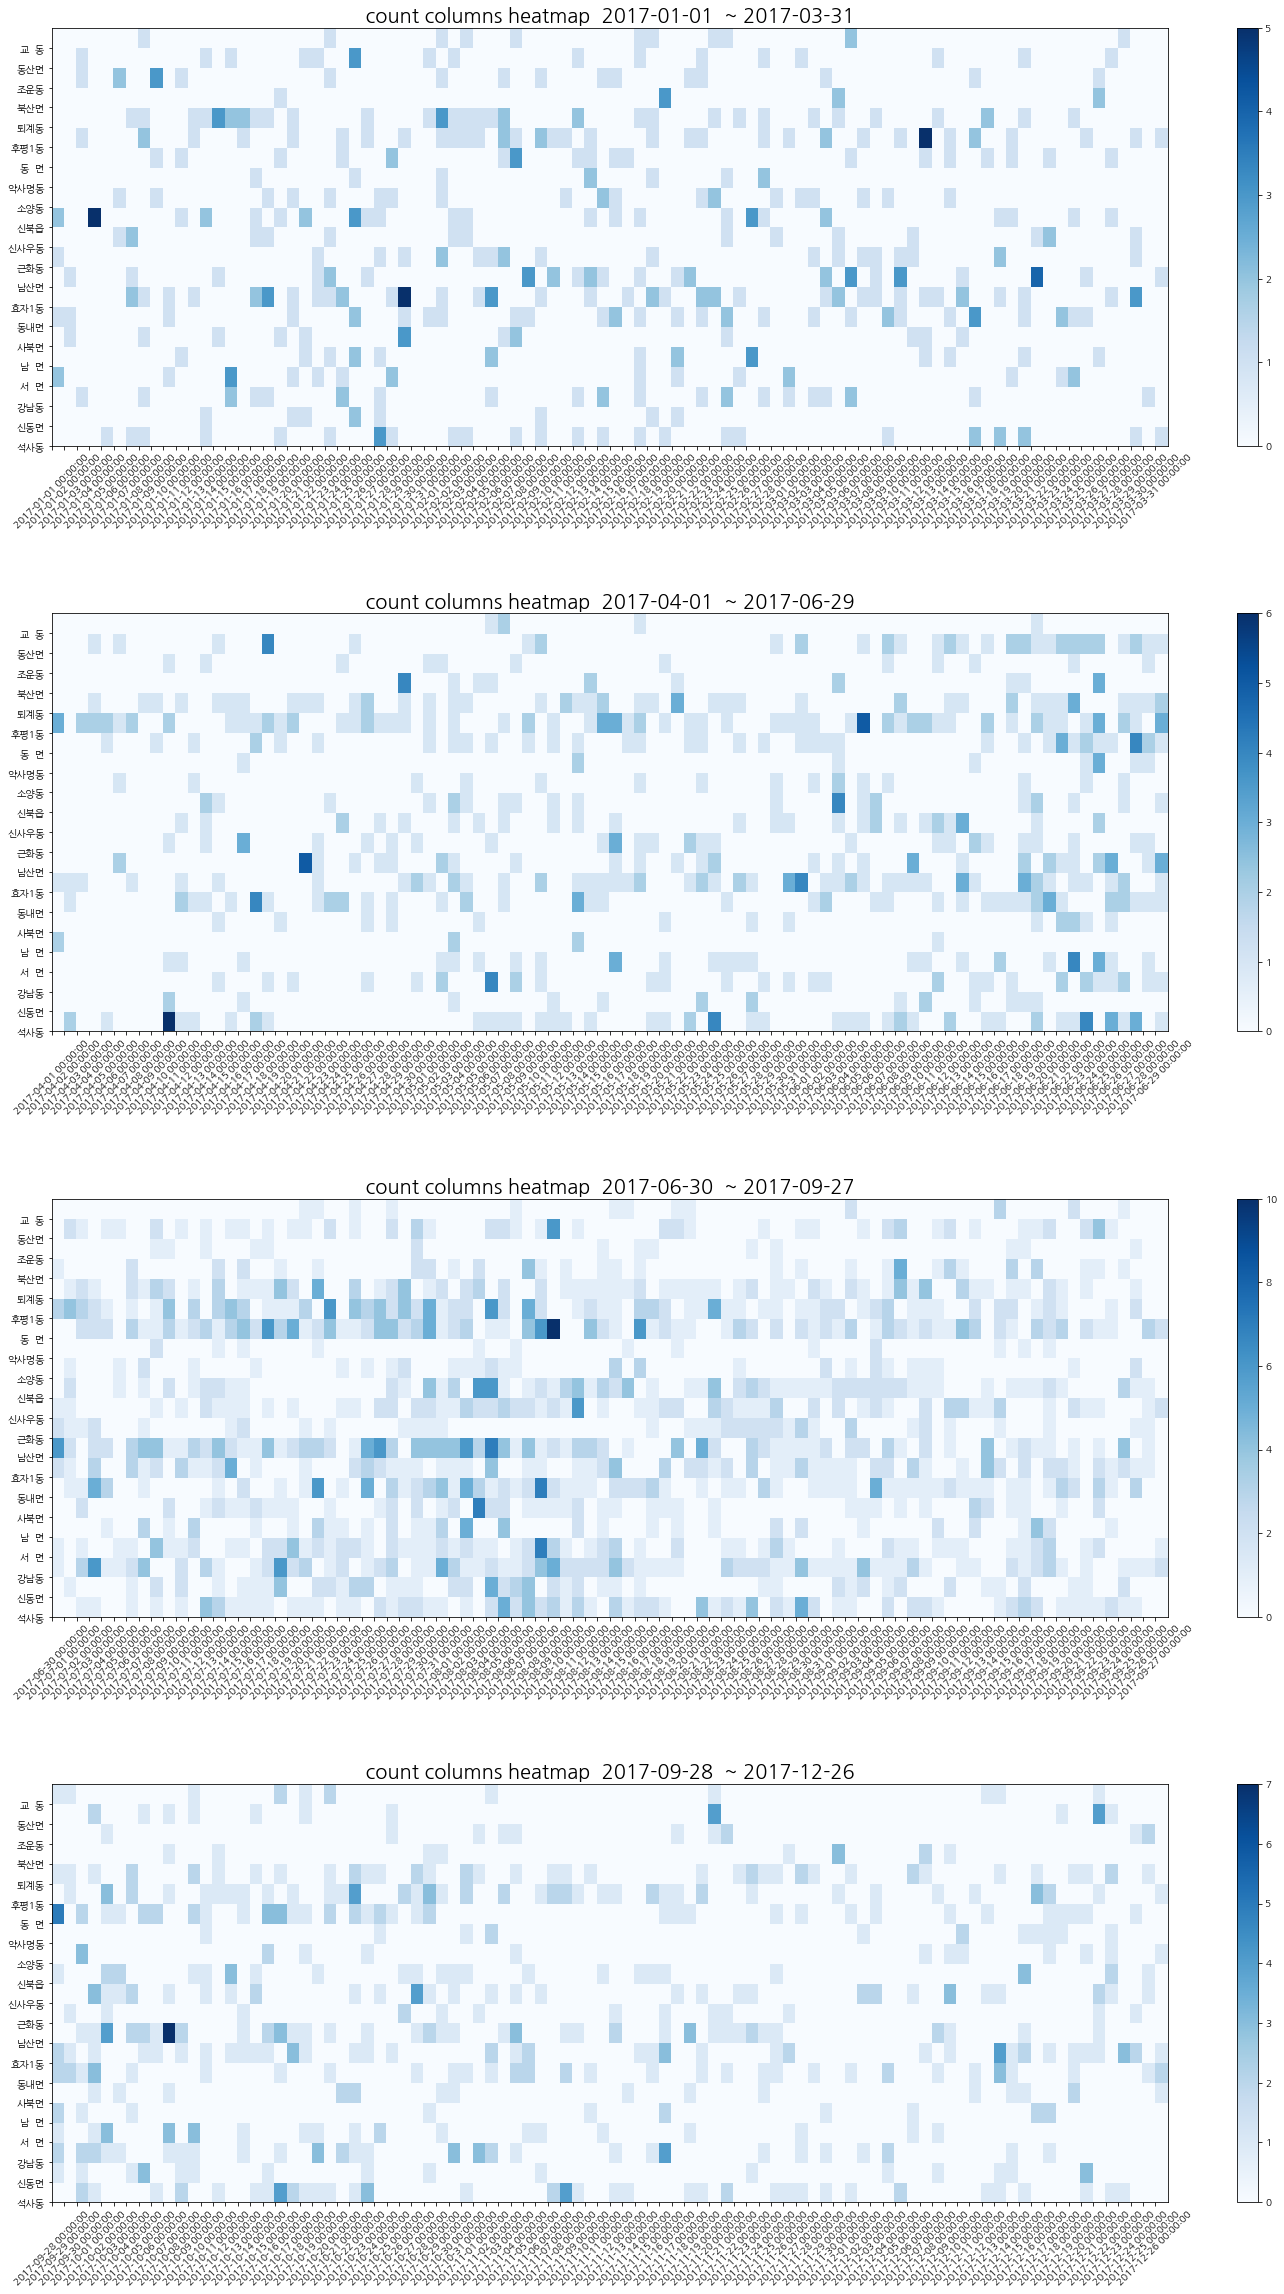

In [19]:
y_df = year_df_sum(data , 2017)
get_col_heatmap(y_df, 'count' , 2017)

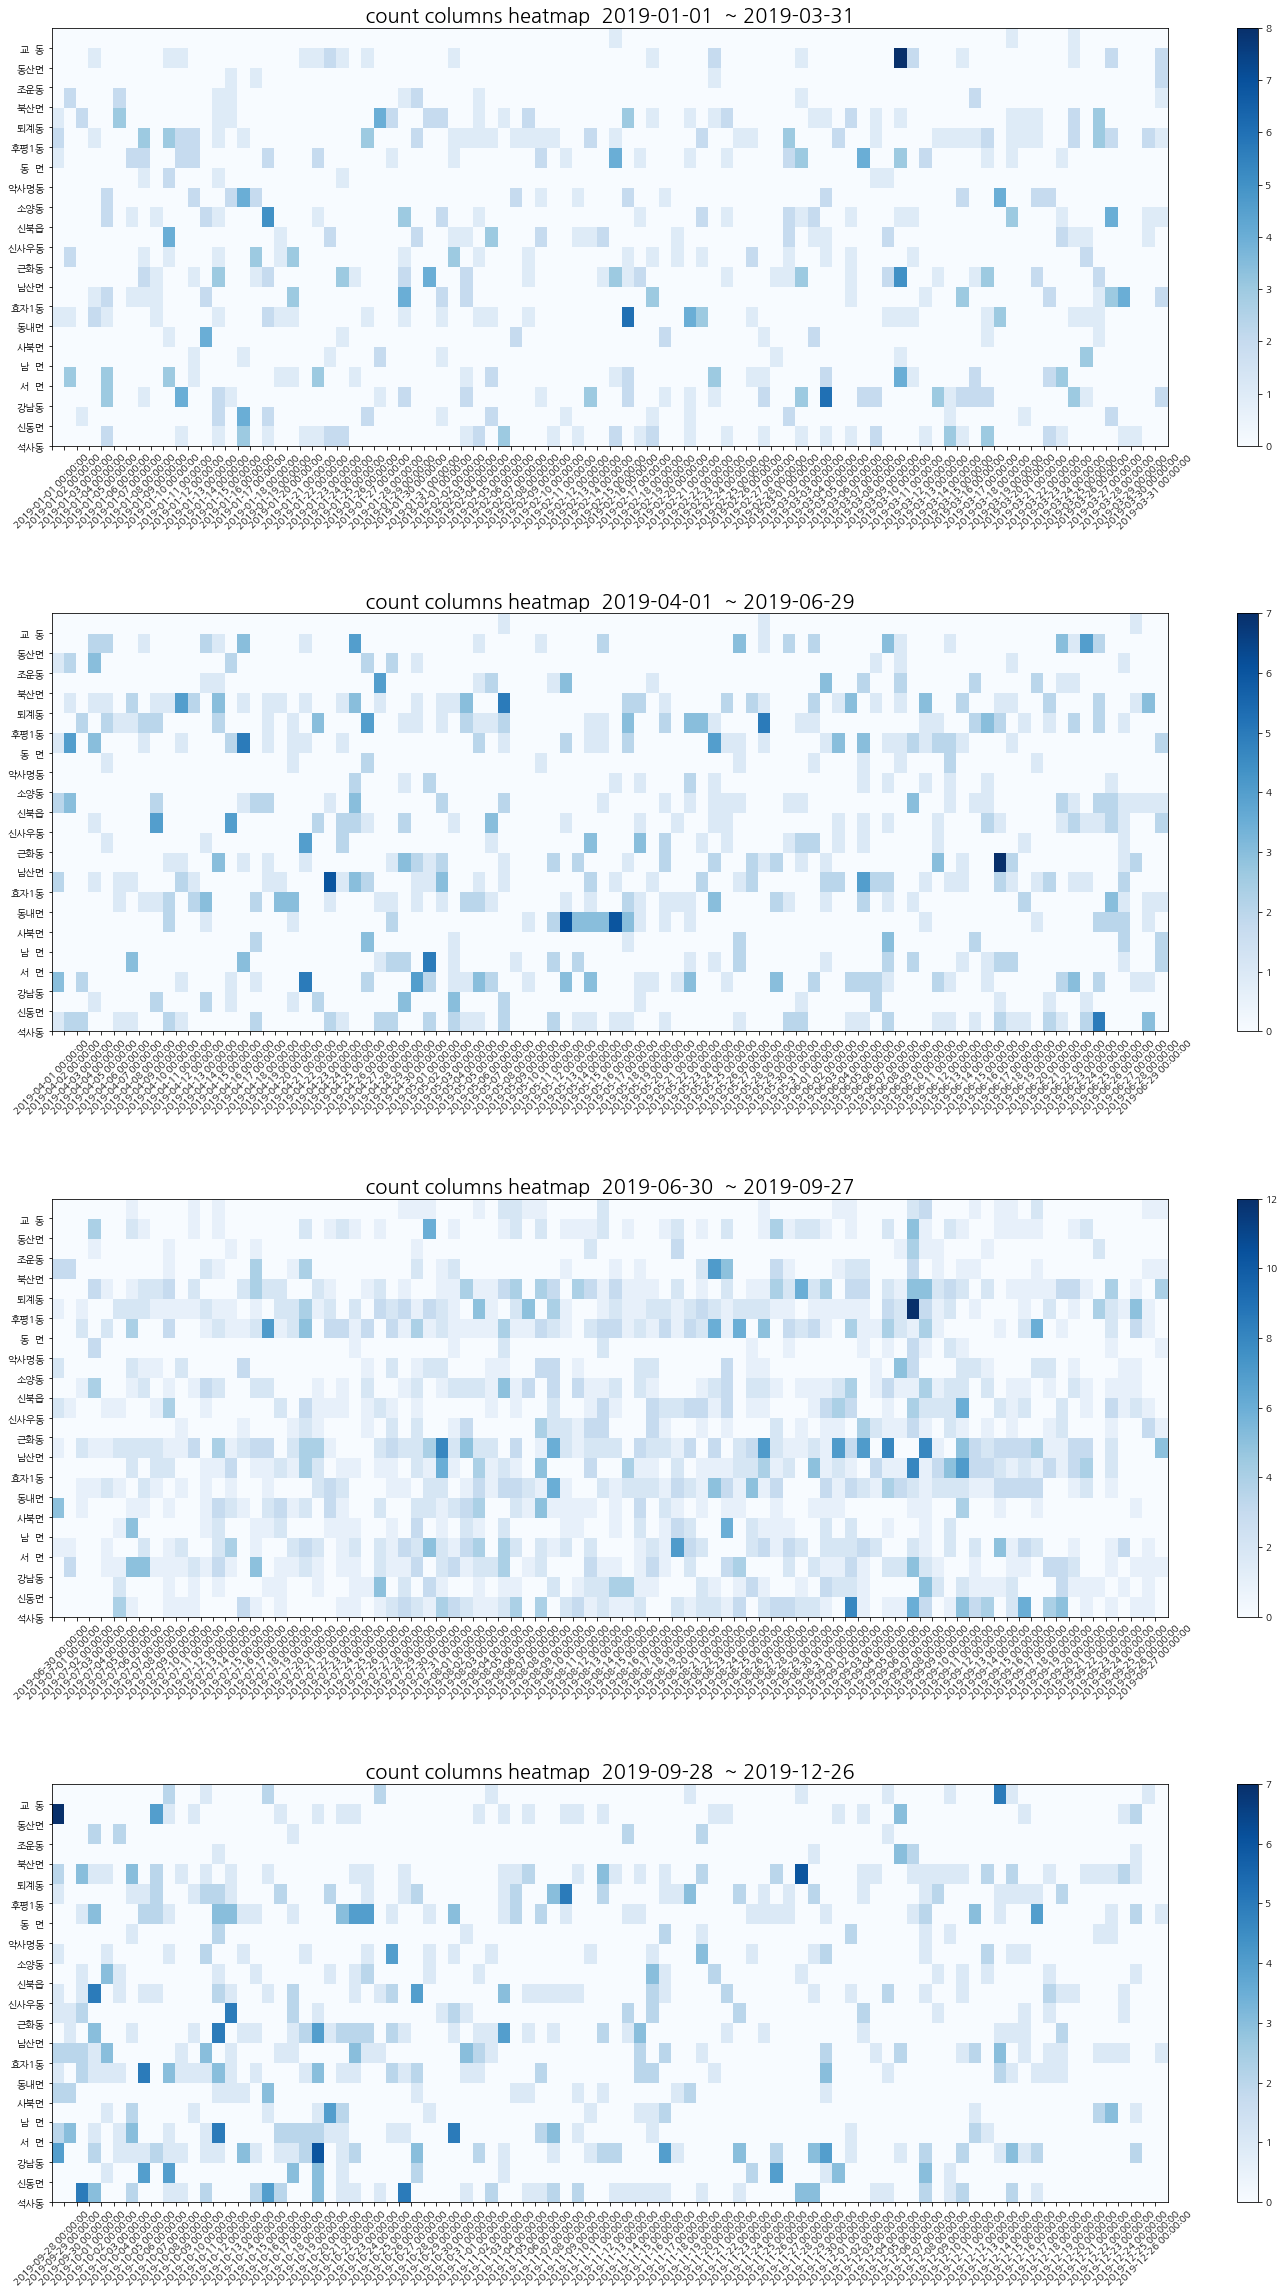

In [20]:
y_df = year_df_sum(data , 2019)
get_col_heatmap(y_df, 'count' , 2019)

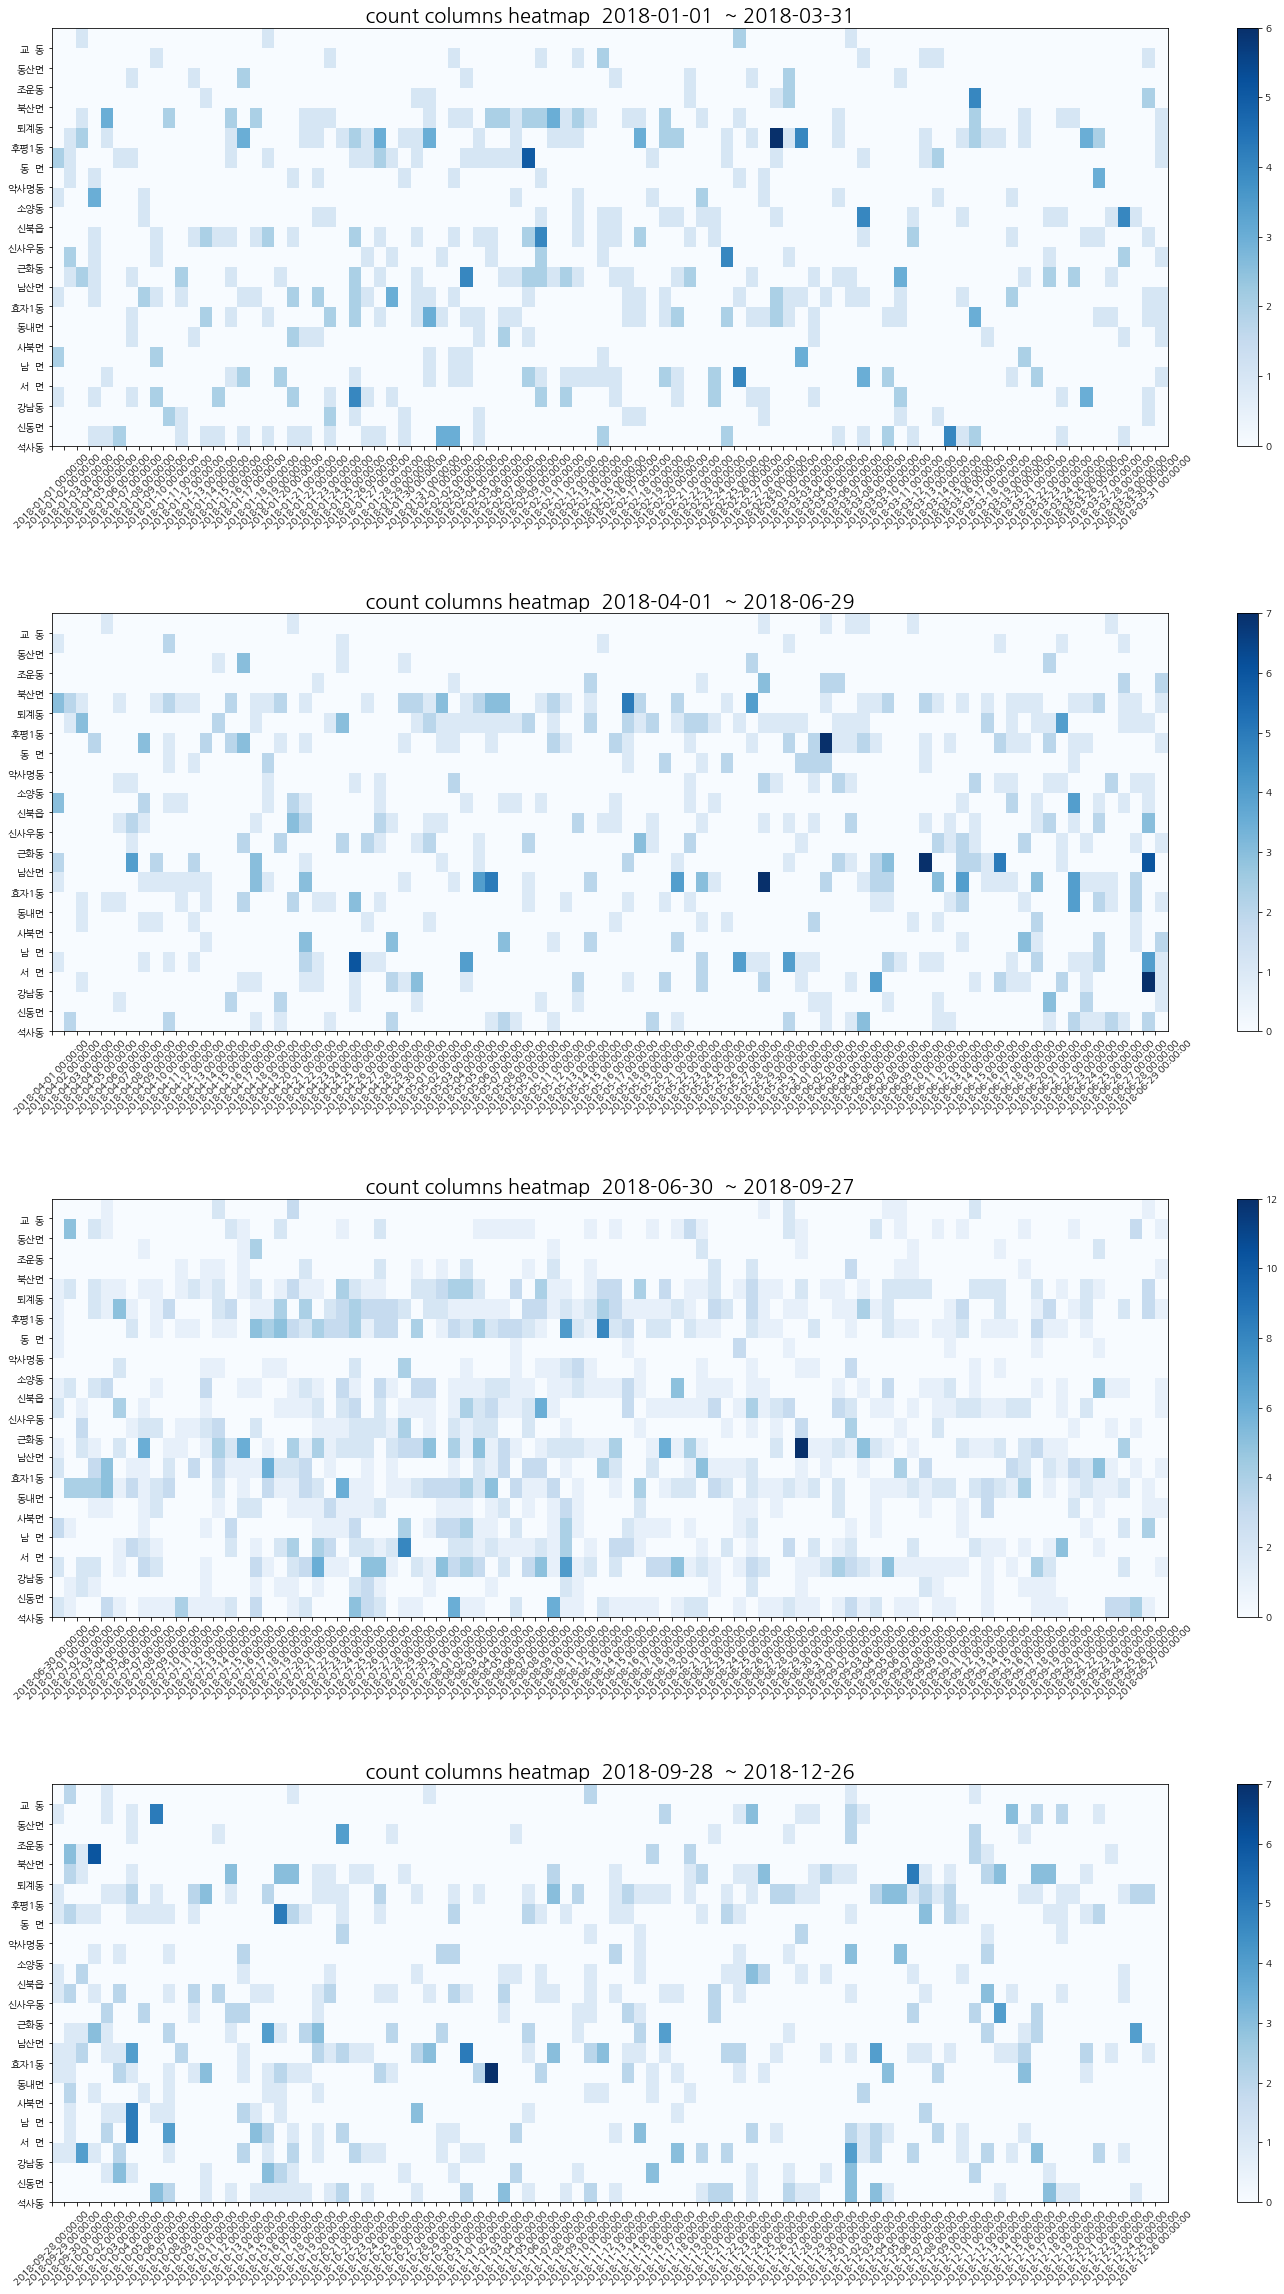

In [21]:
y_df = year_df_sum(data , 2018)
get_col_heatmap(y_df, 'count' , 2018)

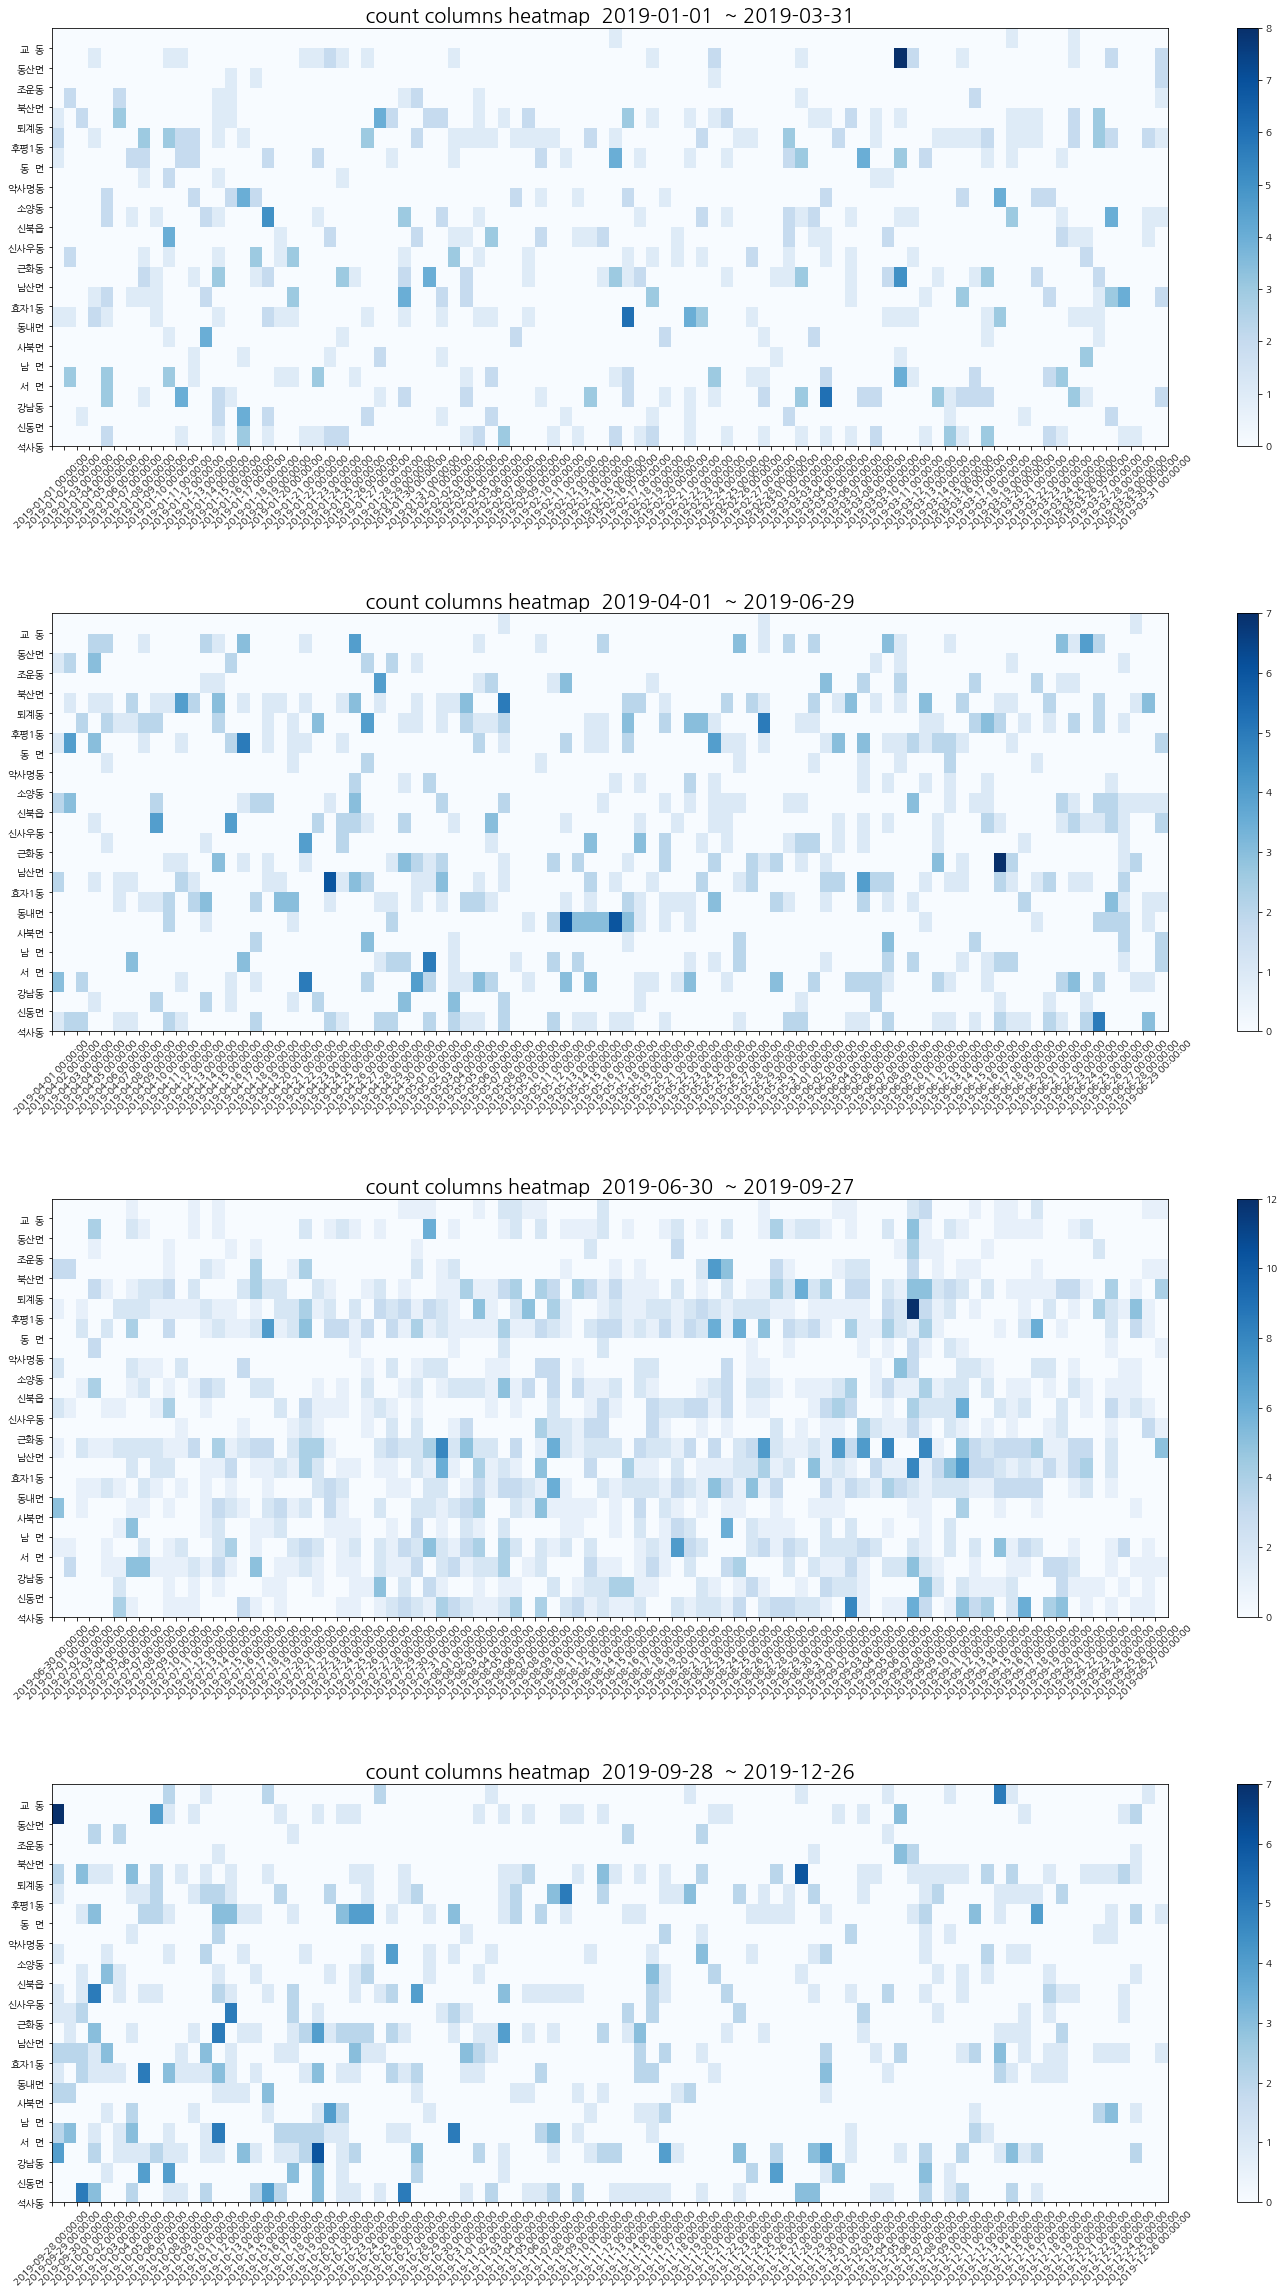

In [22]:
y_df = year_df_sum(data , 2019)
get_col_heatmap(y_df, 'count' , 2019)

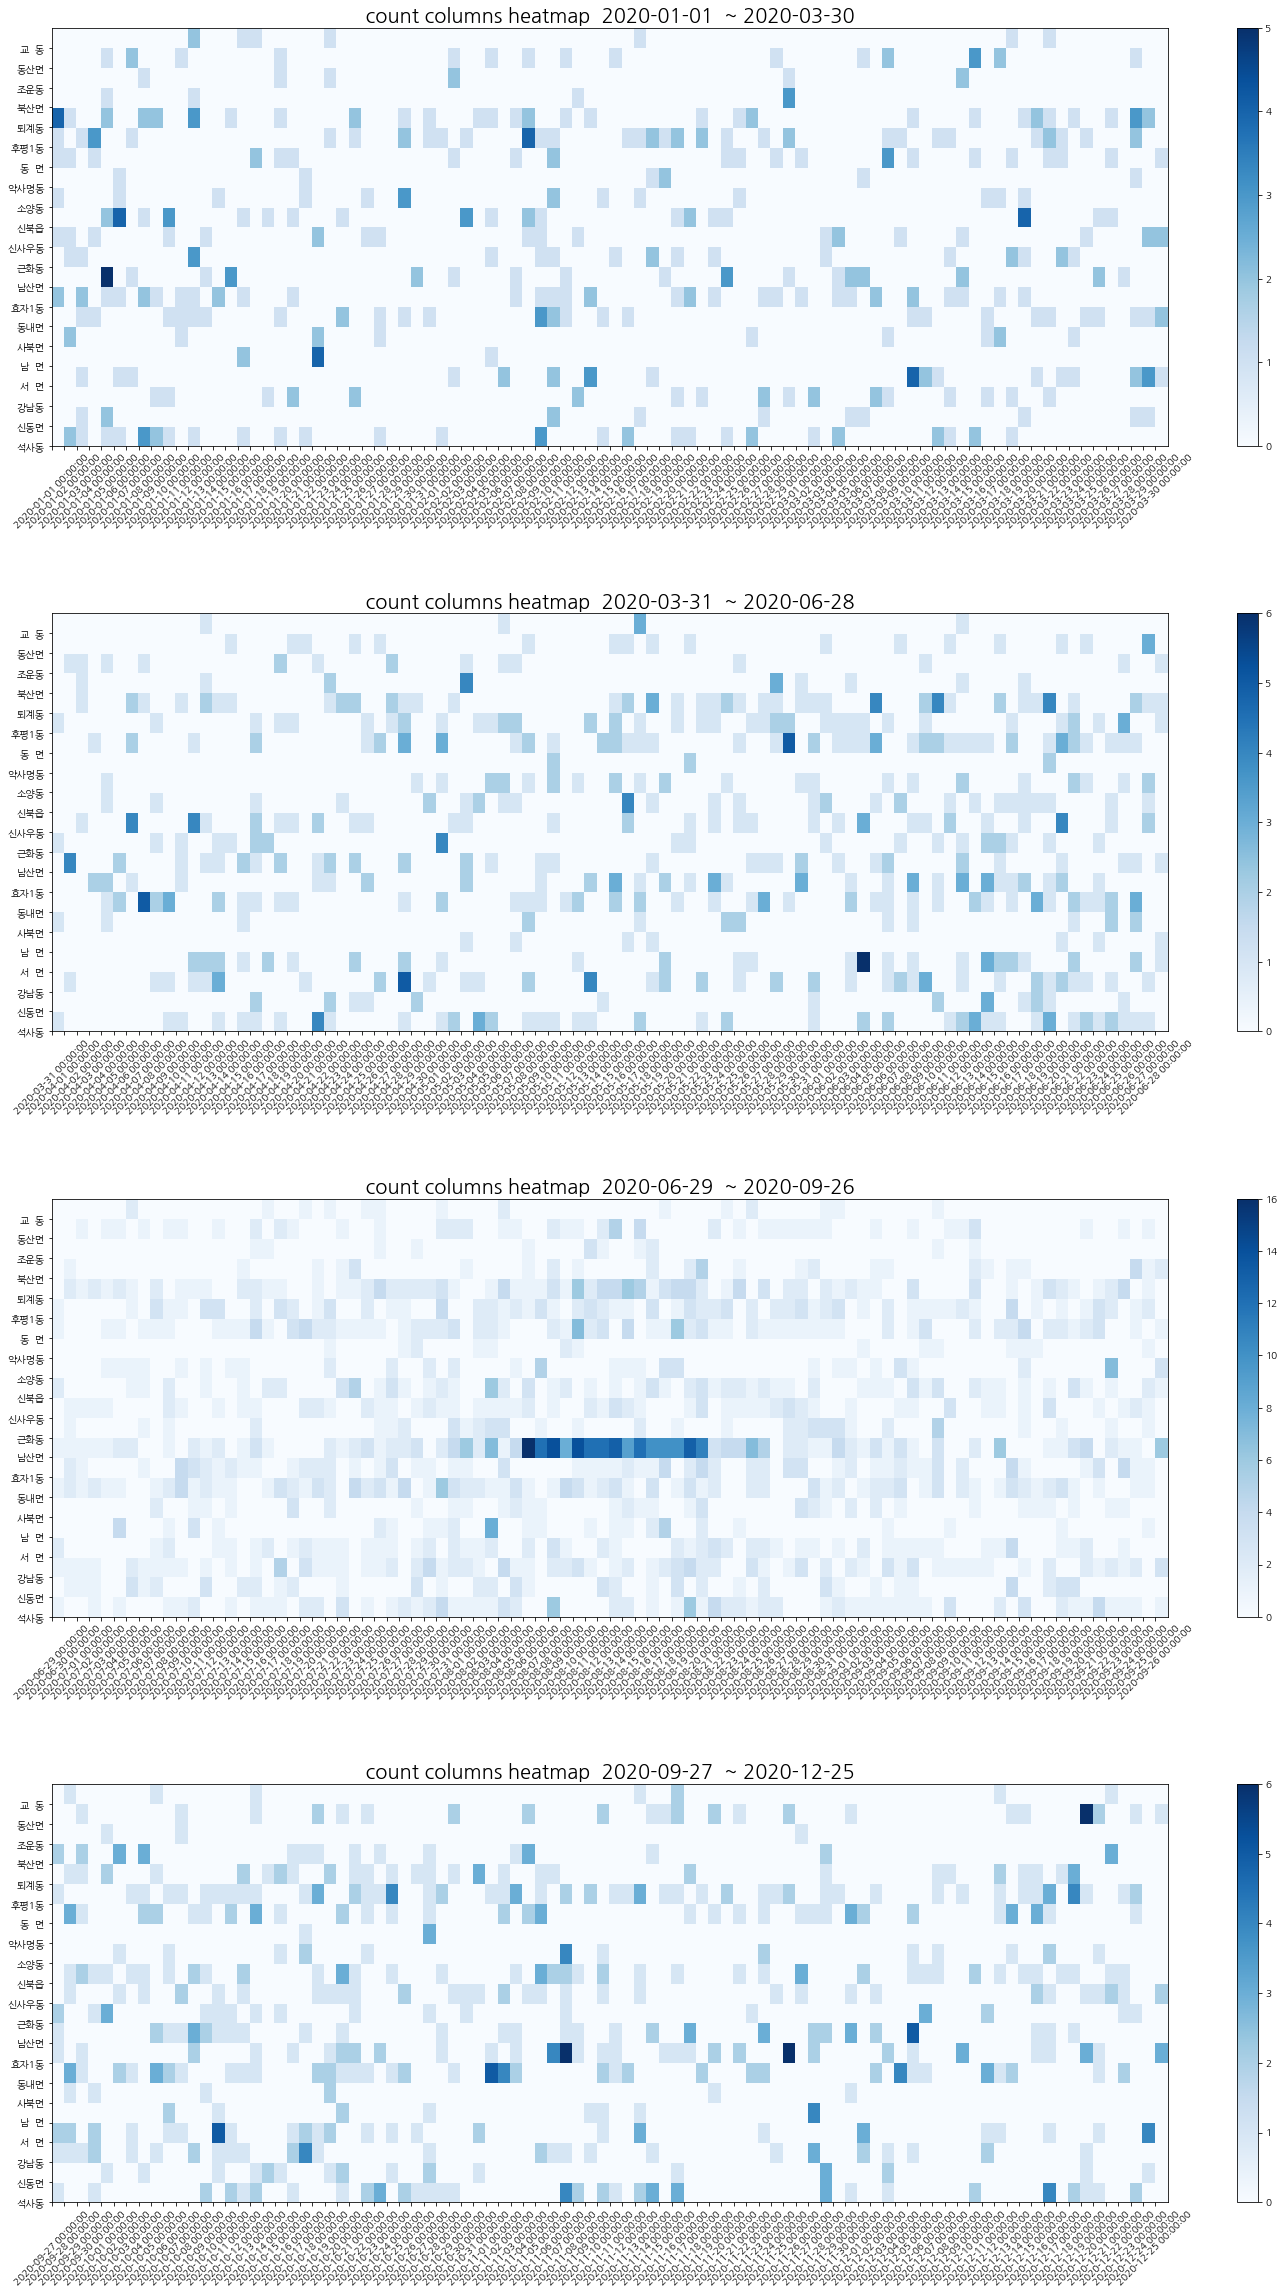

In [23]:
y_df = year_df_sum(data , 2020)
get_col_heatmap(y_df, 'count' , 2020)